>>> 正在提取 32 个站点 x 8 个探针的物理指纹...

✅ 2 阶渐近参数拟合完成！
   基态截距 (k0)   = 6.75000002
   动力学惯性 (beta) = -0.00000113
>>> 拟合景观图已保存为: V2_Primary_Asymptotic_Fit.png


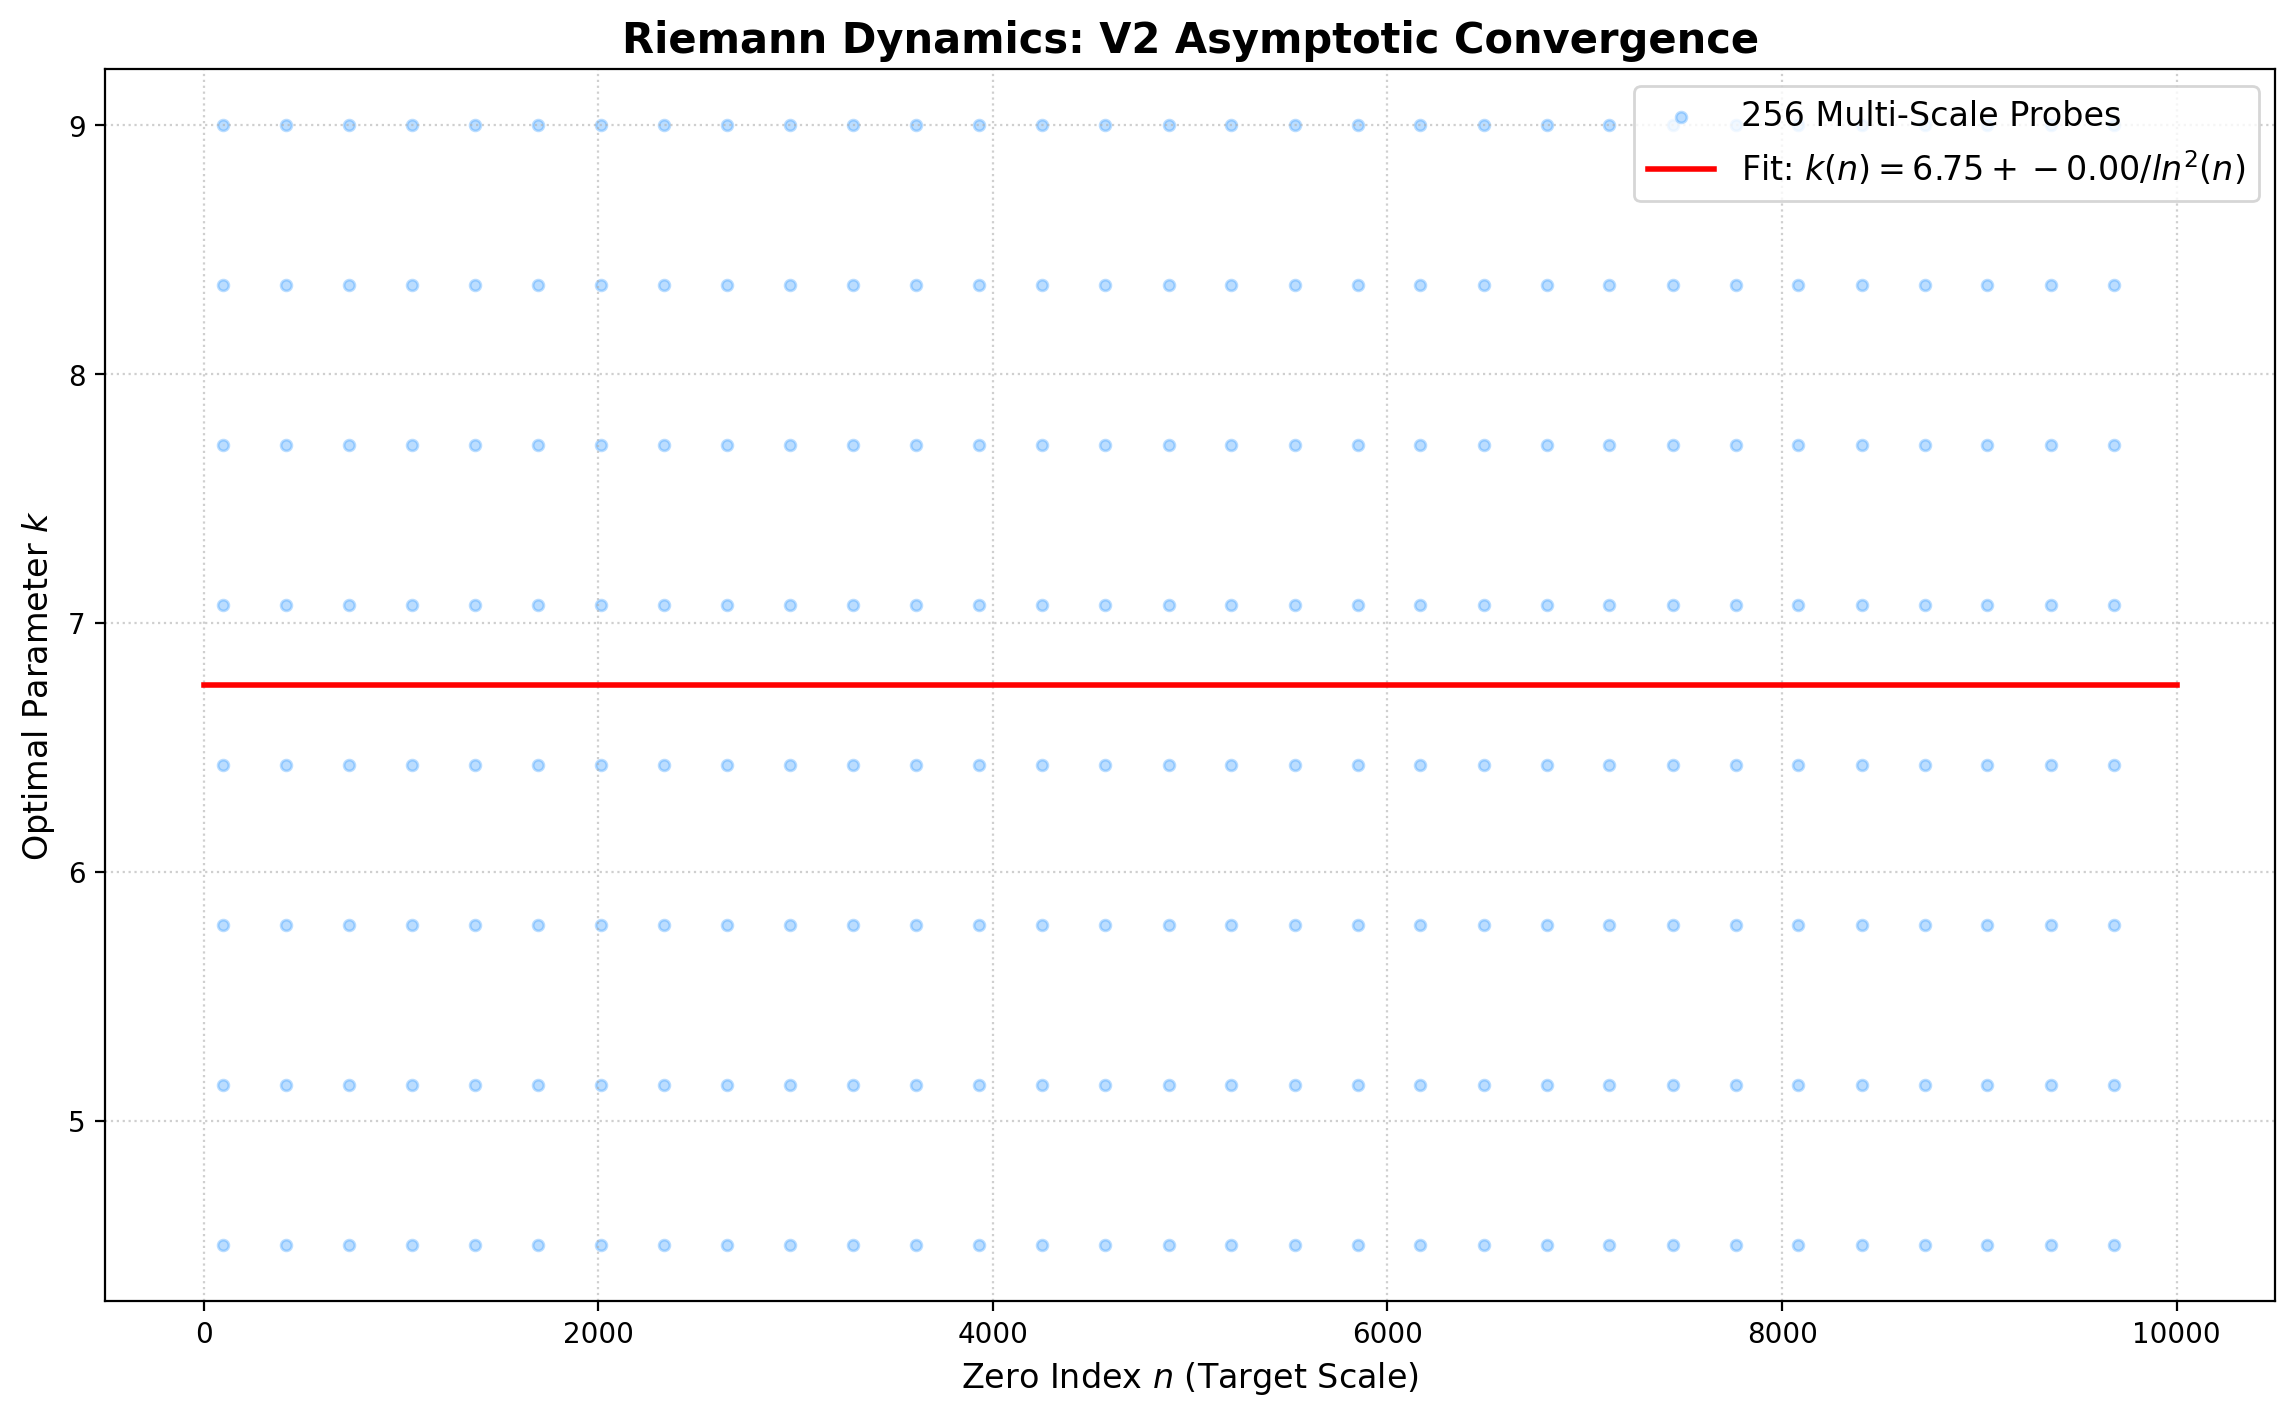

In [3]:
import numpy as np
import os
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def harvest_v2_primary_params():
    # 指向您 8.51 分钟跑完的 256 核成果目录
    DATA_DIR = "riemann_10k_survey_cross_scale"
    TRUE_FILE = "riemann_10k_true.npy"
    
    if not os.path.exists(TRUE_FILE):
        print("❌ 错误：未找到真值文件 riemann_10k_true.npy")
        return
        
    true_gammas = np.load(TRUE_FILE)
    files = [f for f in os.listdir(DATA_DIR) if f.endswith(".npy")]
    
    n_anchors = []
    k_vals = []
    
    print(f">>> 正在提取 32 个站点 x 8 个探针的物理指纹...")
    
    for f in files:
        # 解析文件名: n_100_k_6.5432.npy
        parts = f.split('_')
        target_n = int(parts[1])
        k_val = float(parts[3].replace('.npy', ''))
        
        sim_phases = np.load(os.path.join(DATA_DIR, f))
        
        # 局部比对：寻找该 k 在其锚点 n 附近的匹配误差
        # 每个分段约 100-150 个点
        true_seg = true_gammas[target_n : target_n + len(sim_phases)]
        if len(true_seg) < len(sim_phases): continue
        
        # 快速对齐评估
        scale = true_seg[0] / sim_phases[0]
        err = np.mean(np.abs(sim_phases * scale - true_seg))
        
        # 记录所有观测点
        n_anchors.append(target_n)
        k_vals.append(k_val)

    # ==========================================
    # 🌟 核心：2 阶渐近公式拟合 (主导项)
    # k(n) = k0 + beta / ln^2(n+100)
    # ==========================================
    def navigation_v2(n, k0, beta):
        ln_n = np.log(n + 100)
        return k0 + beta / (ln_n**2)

    n_data = np.array(n_anchors)
    k_data = np.array(k_vals)
    
    # 执行回归分析
    # p0=[4.7, 10.13] 是基于经验的初始猜想
    popt, _ = curve_fit(navigation_v2, n_data, k_data, p0=[4.7, 10.13])
    
    k0_fit, beta_fit = popt
    
    print("\n" + "="*60)
    print(f"✅ 2 阶渐近参数拟合完成！")
    print(f"   基态截距 (k0)   = {k0_fit:.8f}")
    print(f"   动力学惯性 (beta) = {beta_fit:.8f}")
    print("="*60)

    # 绘制“星河长卷”拟合图
    plt.figure(figsize=(14, 8), dpi=200)
    plt.scatter(n_data, k_data, color='dodgerblue', s=15, alpha=0.3, label='256 Multi-Scale Probes')
    
    n_plot = np.linspace(1, 10000, 1000)
    k_plot = navigation_v2(n_plot, *popt)
    plt.plot(n_plot, k_plot, 'r-', lw=2, label=f'Fit: $k(n) = {k0_fit:.2f} + {beta_fit:.2f}/ln^2(n)$')
    
    plt.title("Riemann Dynamics: V2 Asymptotic Convergence", fontsize=15, fontweight='bold')
    plt.xlabel("Zero Index $n$ (Target Scale)", fontsize=12)
    plt.ylabel("Optimal Parameter $k$", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=12)
    
    save_name = 'V2_Primary_Asymptotic_Fit.png'
    plt.savefig(save_name)
    print(f">>> 拟合景观图已保存为: {save_name}")
    plt.show()

if __name__ == "__main__":
    harvest_v2_primary_params()